In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset, random_split
import sys
import os

# Adds folder to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import get_absorptance, si_eps, get_sine_eps, get_weighted_absorptance

sim_dtype = torch.complex64
geo_dtype = torch.float32

In [13]:
Loaded = torch.load("../Data/Modulated_Silicon_Data_5000_structures.pt")

In [14]:
class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size, hidden_layers, hidden_nodes):
        super(MLP, self).__init__()
        layers = []
        layers.append(torch.nn.Linear(input_size, hidden_nodes))
        layers.append(torch.nn.ReLU())
        for _ in range(hidden_layers - 1):
            layers.append(torch.nn.Linear(hidden_nodes, hidden_nodes))
            layers.append(torch.nn.ReLU())
        layers.append(torch.nn.Linear(hidden_nodes, output_size))
        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() == 3:
            amplitudes = x[:, :, 0]
            phases = x[:, :, 1]
            an = amplitudes * torch.cos(phases)
            bn = amplitudes * torch.sin(phases)
            x = torch.cat((an, bn),dim=1)
        return self.network(x)

In [15]:
class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size, hidden_layers, hidden_nodes, dropout_prob=0.2):
        super(MLP, self).__init__()
        
        # Store dropout probability
        self.dropout_prob = dropout_prob
        layers = []
        
        # First Hidden Layer
        layers.append(torch.nn.Linear(input_size, hidden_nodes))
        layers.append(torch.nn.ReLU())
        # Dropout to prevent overfitting
        layers.append(torch.nn.Dropout(self.dropout_prob))
        
        # Subsequent Hidden Layers
        for _ in range(hidden_layers - 1):
            layers.append(torch.nn.Linear(hidden_nodes, hidden_nodes))
            layers.append(torch.nn.ReLU())
            layers.append(torch.nn.Dropout(self.dropout_prob))
            
        #Output Layer
        layers.append(torch.nn.Linear(hidden_nodes, output_size))
        
        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() == 3:
            # Polar-to-Cartesian Feature Transformation
            amplitudes = x[:, :, 0]
            phases = x[:, :, 1]
            an = amplitudes * torch.cos(phases)
            bn = amplitudes * torch.sin(phases)
            x = torch.cat((an, bn),dim=1)
        return self.network(x)

In [92]:
#Make a simple dataloader to check the data
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = TensorDataset(Loaded['features'].to(device), Loaded['targets'].to(device))
total_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
train_size = int(0.80 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [93]:
#initialize the MLP
input_size = 10  # 5 amplitudes + 5 phases
output_size = 2  # Number of absorptance values to predict
hidden_layers = 3
hidden_nodes = 128
model = MLP(input_size, output_size, hidden_layers, hidden_nodes)
criterion = torch.nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4,weight_decay=1e-5)

# convert to GPU if available
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

#Create DataLoaders
BATCH_SIZE = 128 #
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

num_epochs = 5000

#setup losses
train_loss_history = []
val_loss_history = []

best_val_loss = float('inf') # For early stopping
patience = 500              # How many epochs to wait for improvement
patience_counter = 0

pbar = tqdm(range(num_epochs), desc="Training")

for epoch in pbar:
    # Training
    model.train()
    total_train_loss = 0.0
    
    for inputs, targets in train_loader:

        inputs, targets = inputs, targets
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        # Accumulate the batch loss (mean loss per batch)
        total_train_loss += loss.item()
    
    # Calculate average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation
    model.eval() # Set model to evaluation mode
    total_val_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in val_loader: # Use val_loader for validation loss

            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
    
    # Calculate average validation loss for the epoch
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    # Update Pbar and check for early stopping
    pbar.set_description(
        f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4e} | Val Loss: {avg_val_loss:.4e}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Potentially save the best model
        # torch.save(model.state_dict(), 'best_mlp_model.pt')
        
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Validation loss did not improve for {patience} epochs. Stopping early at epoch {epoch+1}.")
            # Optionally save the model here
            # torch.save(model.state_dict(), 'early_stopped_mlp_model.pt')
            break
            

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Validation loss did not improve for 500 epochs. Stopping early at epoch 2290.


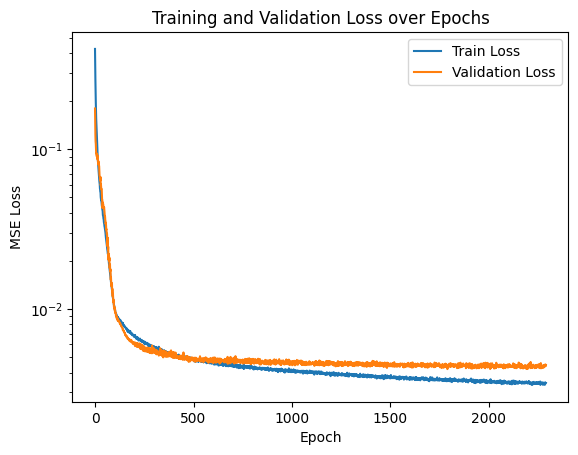

In [95]:
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [74]:
test_param = torch.tensor([[20,0],[20,np.pi],[20,0]],dtype=geo_dtype,device=device)

In [75]:
argmax = torch.argmax(Loaded['targets'][:,1])
best_param = Loaded['features'][argmax].to(device)

In [76]:
get_weighted_absorptance(test_param)

(tensor(0.2934, device='cuda:0', dtype=torch.float64),
 tensor(0.2449, device='cuda:0', dtype=torch.float64))

In [77]:
get_weighted_absorptance(best_param)

(tensor(0.3220, device='cuda:0', dtype=torch.float64),
 tensor(0.2744, device='cuda:0', dtype=torch.float64))

In [78]:
sine_eps = get_sine_eps(torch.linspace(0,1000,1000,device=device),best_param,1000,si_eps(500))

In [96]:
difference = torch.abs(model(Loaded['features'].to(device)) - Loaded['targets'].to(device))
relative_difference = difference / Loaded['targets'].to(device)
percent_difference = relative_difference * 100

In [97]:
percent_difference

tensor([[2.1601, 2.2378],
        [0.2796, 0.0186],
        [0.6667, 0.5476],
        ...,
        [0.0267, 0.3851],
        [1.7379, 2.6191],
        [0.9475, 0.8519]], device='cuda:0', grad_fn=<MulBackward0>)

In [99]:
difference.max()

tensor(0.0229, device='cuda:0', grad_fn=<MaxBackward1>)

In [98]:
percent_difference.max()

tensor(8.7684, device='cuda:0', grad_fn=<MaxBackward1>)

In [58]:
outputs = model(Loaded['features'].to(device))

In [65]:
criterion(outputs, Loaded['targets'].to(device))

tensor(2.1152e-05, device='cuda:0', grad_fn=<MseLossBackward0>)